In [ ]:
import random
import gymnasium as gym
from collections import namedtuple, deque
from itertools import count
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.tensorboard import SummaryWriter  # Import TensorBoard
from dqn import DQN

# Initialize TensorBoard writer
writer = SummaryWriter()

num_episodes = 600
batch_size = 128
GAMMA = 0.99
LR = 1e-4
TAU = 0.005

EPSILON = 1.0  # Start with full exploration
EPSILON_MIN = 0.01  # Minimum value
EPSILON_DECAY = 0.995  # Decay factor per episode

reward_list = []
episode_durations = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

Transition = namedtuple(
    "Transition", ["state", "action", "next_state", "reward", "done"]
)


class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return (
            random.sample(self.memory, batch_size)
            if batch_size < len(self.memory)
            else self.memory
        )

    def __len__(self):
        return len(self.memory)


# Initialize the environment
env = gym.make("LunarLander-v3")

n_observations = env.observation_space.shape[0]
n_actions = env.action_space.n

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

replay_memory = ReplayMemory(10000)


def select_action(state):
    if np.random.rand() < EPSILON:
        return torch.tensor(
            [[env.action_space.sample()]], dtype=torch.long, device=device
        )
    else:
        with torch.no_grad():
            return policy_net(state).max(1).indices.view(1, 1)  # Exploit (best action)


optimizer = optim.AdamW(policy_net.parameters(), lr=LR)
criterion = nn.SmoothL1Loss()

for episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    total_reward = 0

    for t in count():
        action = select_action(state)
        next_state, reward, terminated, truncated, info = env.step(action.item())

        done = terminated or truncated
        reward = torch.tensor([reward], device=device)
        next_state = torch.tensor(
            next_state, dtype=torch.float32, device=device
        ).unsqueeze(0)
        replay_memory.push(state, action, next_state, reward, done)

        state = next_state
        total_reward += reward.item()

        if len(replay_memory) >= batch_size:
            transitions = replay_memory.sample(batch_size)
            states, actions, next_states, rewards, dones = zip(*transitions)

            states_batch = torch.cat(states)
            next_states_batch = torch.cat(next_states)
            actions_batch = torch.cat(actions)
            rewards = torch.tensor(rewards, device=device)
            dones = torch.tensor(dones, device=device)

            q_target = (
                GAMMA * target_net(next_states_batch).detach().max(1)[0] * ~dones
                + rewards
            )
            q_policy = policy_net(states_batch).gather(1, actions_batch)

            # Calculate the Huber loss
            loss = criterion(q_policy, q_target.unsqueeze(1))

            # Optimize the model
            optimizer.zero_grad()
            loss.backward()

            # In-place gradient clipping to stabilize training
            torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)

            optimizer.step()

            # Log loss to TensorBoard
            writer.add_scalar("Loss", loss.item(), episode)

        # Update target network
        for target_param, main_param in zip(
            target_net.parameters(), policy_net.parameters()
        ):
            target_param.data.copy_(
                TAU * main_param.data + (1 - TAU) * target_param.data
            )
        print(f'episode {episode}/ {num_episodes} reward = {total_reward}')
        if done:
            episode_durations.append(t + 1)
            reward_list.append(total_reward)

            # Log metrics to TensorBoard
            writer.add_scalar("Reward", total_reward, episode)
            writer.add_scalar("Episode Duration", t + 1, episode)
            writer.add_scalar("Epsilon", EPSILON, episode)
            break

    # Decay epsilon
    EPSILON = max(EPSILON_MIN, EPSILON * EPSILON_DECAY)

# Close TensorBoard writer
writer.close()

# Save the trained model
torch.save(policy_net.state_dict(), "models/dqn_lunar_lander.pth")
print("Model saved successfully!")

print("Complete")
env.close()


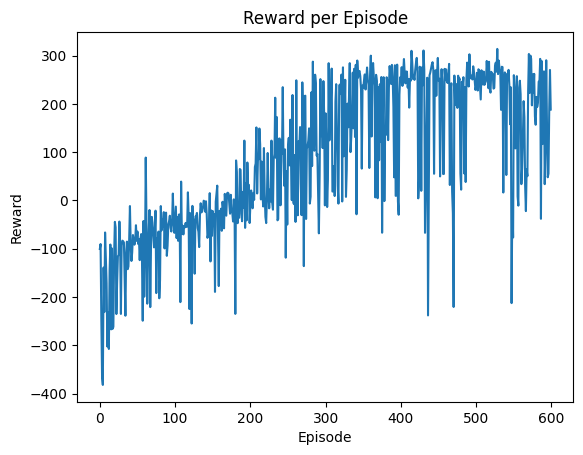

In [3]:
import matplotlib.pyplot as plt
plt.plot(reward_list)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Reward per Episode')
plt.show()

In [3]:
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 2681), started 0:00:07 ago. (Use '!kill 2681' to kill it.)